In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

url = 'https://raw.githubusercontent.com/tiaraara09/Tiara-Azizah-2411533001-ML2526/refs/heads/main/pratikum2/Breast_cancer_data.csv'
df = pd.read_csv(url)

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=16)

In [2]:
model_no_scaling = LogisticRegression(max_iter=1000)
model_no_scaling.fit(X_train, y_train)
acc_no_scaling = model_no_scaling.score(X_test, y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression()
model_scaled.fit(X_train_scaled, y_train)
acc_scaled = model_scaled.score(X_test_scaled, y_test)

print(f"Akurasi Tanpa Scaling: {acc_no_scaling:.4f}")
print(f"Akurasi Dengan Scaling: {acc_scaled:.4f}")



Akurasi Tanpa Scaling: 0.9006
Akurasi Dengan Scaling: 0.9415


In [3]:
y_probs = model_scaled.predict_proba(X_test_scaled)[:, 1]

def evaluate_threshold(threshold):
    y_thresh = (y_probs >= threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_thresh))
for t in [0.3, 0.5, 0.7]:
    evaluate_threshold(t)


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       0.98      0.85      0.91        65
           1       0.91      0.99      0.95       106

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171


--- Threshold: 0.5 ---
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        65
           1       0.94      0.96      0.95       106

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


--- Threshold: 0.7 ---
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        65
           1       0.96      0.90      0.93       106

    accuracy                           0.91       171
   macro avg       0.90      0.92      0.91       171
we

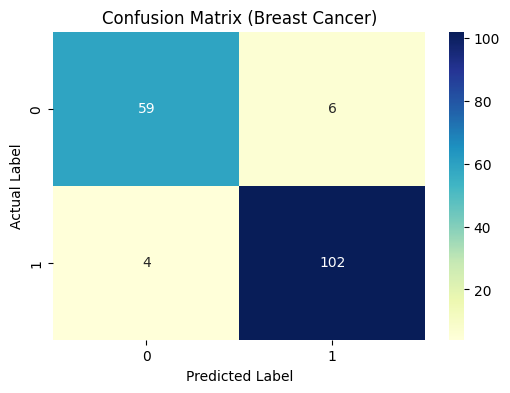

In [4]:
y_pred = model_scaled.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Confusion Matrix (Breast Cancer)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

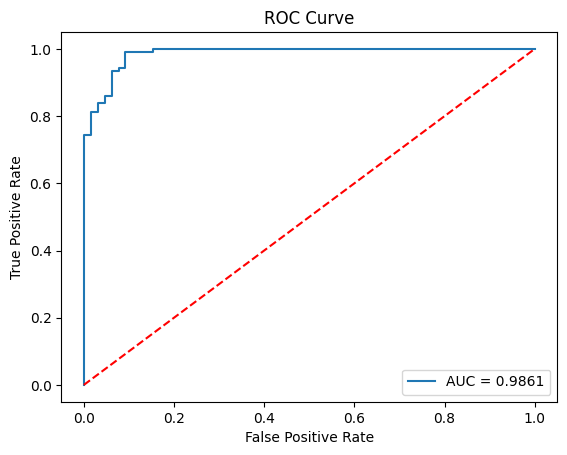

In [5]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.show()

